In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                            classification_report, roc_auc_score)
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
positive_df = pd.read_excel("Anticancer phytochemicals.xlsx")  # 4823 anticancer compounds
negative_df = pd.read_excel("Decoys.xlsx")  # 4823 decoys


positive_df = positive_df[['SMILES']]


positive_df['label'] = 1
negative_df['label'] = 0

In [3]:
positive_df

,SMILES,label
0,CC(=O)C1=CC(=C(C=C1)O)OC,1
1,C#CCCCCCCC#CC#CCCCC=CC#C,1
2,C#CCCCCCCCCCCC#CCCCC=CC#C,1
3,C#CC=CCCCCCCCC=CC#CCCCC=CC#C,1
4,C#CCCCC#CCCCCCCCCC=CC(C#C)O,1
...,...,...
4818,CC(C)CCC(=O)C(C)C1(C(CC2C1(CCC3C2CC=C4C3(CCC(C...,1
4819,CC1C(C(OC2C1C3(CCC4C(C3C2)CC=C5C4(CCC(C5)OC6C(...,1
4820,CC1C(C(OC2C1C3(CCC4C(C3C2)CC=C5C4(CCC(C5)OC6C(...,1
4821,CC1C(C(OC2C1C3(CCC4C(C3C2)CC=C5C4(CCC(C5)OC6C(...,1


In [4]:
negative_df

,SMILE,label
0,CCOC(=O)[C@H](C)NC(C)=O,0
1,CO[C@@H]1CC=CC(=O)[C@H]1OCc1ccccc1,0
2,N#Cc1ccccc1C(=O)NCCCc1ccccc1,0
3,CCCCc1ccc(c2nc(C(=O)OCC)co2)cc1,0
4,NC(=O)C(/C=[N+](\[O-])Cc1ccccc1)Cc1ccccc1,0
...,...,...
4818,CC[C@H]1OC(=O)[C@H](C)[C@@H](OC(=O)N2C(=O)OC[C...,0
4819,O=C(NS(=O)(=O)c1ccc(N[C@H](CC[NH+]2CCOCC2)CSc2...,0
4820,CCCCN(CCCC)C(=O)c1nn(c2ccc(C(=O)NS(=O)(=O)c3cc...,0
4821,C[NH+](C)CCCNc1ccc(S(=O)(=O)NC(=O)c2nc(N3CCc4c...,0


In [5]:
df = pd.concat([positive_df, negative_df], ignore_index=True)

In [6]:
df

,SMILES,label,SMILE
0,CC(=O)C1=CC(=C(C=C1)O)OC,1,NaN
1,C#CCCCCCCC#CC#CCCCC=CC#C,1,NaN
2,C#CCCCCCCCCCCC#CCCCC=CC#C,1,NaN
3,C#CC=CCCCCCCCC=CC#CCCCC=CC#C,1,NaN
4,C#CCCCC#CCCCCCCCCC=CC(C#C)O,1,NaN
...,...,...,...
9641,NaN,0,CC[C@H]1OC(=O)[C@H](C)[C@@H](OC(=O)N2C(=O)OC[C...
9642,NaN,0,O=C(NS(=O)(=O)c1ccc(N[C@H](CC[NH+]2CCOCC2)CSc2...
9643,NaN,0,CCCCN(CCCC)C(=O)c1nn(c2ccc(C(=O)NS(=O)(=O)c3cc...
9644,NaN,0,C[NH+](C)CCCNc1ccc(S(=O)(=O)NC(=O)c2nc(N3CCc4c...


In [7]:
df['smiles'] = df['SMILES'].fillna(df['SMILE'])

In [8]:
df = df.drop(columns=['SMILES', 'SMILE'])

df = df.reset_index(drop=True)
print(df.head())

   label                        smiles
0      1      CC(=O)C1=CC(=C(C=C1)O)OC
1      1      C#CCCCCCCC#CC#CCCCC=CC#C
2      1     C#CCCCCCCCCCCC#CCCCC=CC#C
3      1  C#CC=CCCCCCCCC=CC#CCCCC=CC#C
4      1   C#CCCCC#CCCCCCCCCC=CC(C#C)O


In [9]:
df

,label,smiles
0,1,CC(=O)C1=CC(=C(C=C1)O)OC
1,1,C#CCCCCCCC#CC#CCCCC=CC#C
2,1,C#CCCCCCCCCCCC#CCCCC=CC#C
3,1,C#CC=CCCCCCCCC=CC#CCCCC=CC#C
4,1,C#CCCCC#CCCCCCCCCC=CC(C#C)O
...,...,...
9641,0,CC[C@H]1OC(=O)[C@H](C)[C@@H](OC(=O)N2C(=O)OC[C...
9642,0,O=C(NS(=O)(=O)c1ccc(N[C@H](CC[NH+]2CCOCC2)CSc2...
9643,0,CCCCN(CCCC)C(=O)c1nn(c2ccc(C(=O)NS(=O)(=O)c3cc...
9644,0,C[NH+](C)CCCNc1ccc(S(=O)(=O)NC(=O)c2nc(N3CCc4c...


In [10]:
def compute_descriptors(smiles_list):
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(
        [x[0] for x in Descriptors._descList]
    )
    desc_names = calc.GetDescriptorNames()
    
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    descriptors = []
    
    for mol in mols:
        if mol is None:
            descriptors.append([np.nan]*len(desc_names))
        else:
            descriptors.append(list(calc.CalcDescriptors(mol)))
    
    return pd.DataFrame(descriptors, columns=desc_names)

In [ ]:
desc_df = compute_descriptors(df['smiles'])
desc_df.fillna(desc_df.median(), inplace=True)

In [14]:
from rdkit.Chem import rdFingerprintGenerator

def compute_ecfp(mols, radius=2, nBits=2048):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)
    fps = []
    for m in mols:
        if m is None:
            fps.append([0] * nBits)
        else:
            fp = gen.GetFingerprint(m)   # RDKit ExplicitBitVect
            fps.append(list(fp))
    return fps

In [15]:
mols = [Chem.MolFromSmiles(smi) for smi in df['smiles'] if smi is not None]
ecfp = compute_ecfp(mols)


In [25]:
X_desc = desc_df.values                     
X_fp   = ecfp                               
X = np.hstack([X_desc, X_fp])              
y = df['label'].values 

In [16]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

results = []
best_scores = {"RF": 0, "SVM": 0, "KNN": 0}

for run in range(1, 11):

    print(f"\n========== RUN {run} ==========")

    # 1. Train–test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

    # 2. Preprocessing
    n_desc = X_desc.shape[1]
    X_desc_train, X_fp_train = X_train[:, :n_desc], X_train[:, n_desc:]
    X_desc_test,  X_fp_test  = X_test[:, :n_desc],  X_test[:, n_desc:]

    scaler = StandardScaler()
    X_desc_train_scaled = scaler.fit_transform(X_desc_train)
    X_desc_test_scaled  = scaler.transform(X_desc_test)

    pca = PCA(n_components=0.95, svd_solver="full")
    X_desc_train_pca = pca.fit_transform(X_desc_train_scaled)
    X_desc_test_pca  = pca.transform(X_desc_test_scaled)

    X_train_comb = np.hstack([X_desc_train_pca, X_fp_train])
    X_test_comb  = np.hstack([X_desc_test_pca,  X_fp_test])

    # ================= RANDOM FOREST =================
    rf_grid = GridSearchCV(
        RandomForestClassifier(n_jobs=-1),
        {"n_estimators":[100,200,300,400,500],
         "max_depth":[5,10,15,20,25,30,35,40]},
        cv=10, scoring="accuracy", n_jobs=-1
    )
    rf_grid.fit(X_train_comb, y_train)
    rf = rf_grid.best_estimator_

    # ================= SVM =================
    svm_grid = GridSearchCV(
        SVC(probability=True),
        {"C":[1,10,100], "gamma":["auto",0.001,0.01,0.1]},
        cv=10, scoring="accuracy", n_jobs=-1
    )
    svm_grid.fit(X_train_comb, y_train)
    svm = svm_grid.best_estimator_

    # ================= KNN =================
    knn_grid = GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors":list(range(1,11)),
         "weights":["uniform","distance"],
         "metric":["euclidean","manhattan"]},
        cv=10, scoring="accuracy", n_jobs=-1
    )
    knn_grid.fit(X_train_comb, y_train)
    knn = knn_grid.best_estimator_

    models = [
        ("RF", rf, rf_grid.best_score_, rf_grid.best_params_),
        ("SVM", svm, svm_grid.best_score_, svm_grid.best_params_),
        ("KNN", knn, knn_grid.best_score_, knn_grid.best_params_)
    ]

    for name, model, cv_acc, best_params in models:

        y_train_prob = model.predict_proba(X_train_comb)[:, 1]
        y_test_prob  = model.predict_proba(X_test_comb)[:, 1]
        y_train_pred = model.predict(X_train_comb)
        y_test_pred  = model.predict(X_test_comb)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)

        print(f"{name}")
        print(f"CV Accuracy   : {cv_acc:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Test Accuracy : {test_acc:.4f}")
        print("Best Params   :", best_params)

        row = {
            "Run": run,
            "Model": name,
            "CV_Accuracy": cv_acc,
            "Train_Accuracy": train_acc,
            "Test_Accuracy": test_acc,
            "Train_ROC_AUC": roc_auc_score(y_train, y_train_prob),
            "Test_ROC_AUC": roc_auc_score(y_test, y_test_prob),
            "Precision": precision_score(y_test, y_test_pred),
            "Recall": recall_score(y_test, y_test_pred),
            "F1": f1_score(y_test, y_test_pred),
            "MCC": matthews_corrcoef(y_test, y_test_pred),
            "Best_Params": best_params
        }

        results.append(row)

        if test_acc > best_scores[name]:
            best_scores[name] = test_acc

            joblib.dump(model, f"BEST_{name}_MODEL.pkl")
            joblib.dump(scaler, f"BEST_{name}_scaler.pkl")
            joblib.dump(pca, f"BEST_{name}_pca.pkl")

            np.save(f"BEST_{name}_X_train.npy", X_train)
            np.save(f"BEST_{name}_X_test.npy", X_test)
            np.save(f"BEST_{name}_y_train.npy", y_train)
            np.save(f"BEST_{name}_y_test.npy", y_test)
            np.save(f"BEST_{name}_X_train_comb.npy", X_train_comb)
            np.save(f"BEST_{name}_X_test_comb.npy", X_test_comb)

results_df = pd.DataFrame(results)
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

print(results_df)

print("\nBEST TEST ACCURACY PER MODEL:")
print(best_scores)


========== RUN 1 ==========
RF
CV Accuracy   : 0.9523
Train Accuracy: 0.9970
Test Accuracy : 0.9534
Best Params   : {'max_depth': 25, 'n_estimators': 400}
SVM
CV Accuracy   : 0.9585
Train Accuracy: 0.9933
Test Accuracy : 0.9663
Best Params   : {'C': 100, 'gamma': 'auto'}
KNN
CV Accuracy   : 0.9388
Train Accuracy: 0.9605
Test Accuracy : 0.9394
Best Params   : {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'uniform'}

========== RUN 2 ==========
RF
CV Accuracy   : 0.9526
Train Accuracy: 0.9961
Test Accuracy : 0.9508
Best Params   : {'max_depth': 25, 'n_estimators': 500}
SVM
CV Accuracy   : 0.9610
Train Accuracy: 0.9789
Test Accuracy : 0.9539
Best Params   : {'C': 10, 'gamma': 0.001}
KNN
CV Accuracy   : 0.9416
Train Accuracy: 0.9629
Test Accuracy : 0.9337
Best Params   : {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'uniform'}

========== RUN 3 ==========
RF
CV Accuracy   : 0.9513
Train Accuracy: 1.0000
Test Accuracy : 0.9513
Best Params   : {'max_depth': 35, 'n_estimators':

In [17]:
results_df

,Run,Model,CV_Accuracy,Train_Accuracy,Test_Accuracy,Train_ROC_AUC,Test_ROC_AUC,Precision,Recall,F1,MCC,Best_Params
0,1,RF,0.952309,0.997019,0.953368,1.000000,0.987124,0.959077,0.947150,0.953076,0.906806,"{'max_depth': 25, 'n_estimators': 400}"
1,1,SVM,0.958527,0.993261,0.966321,0.999578,0.989904,0.962963,0.969948,0.966443,0.932667,"{'C': 100, 'gamma': 'auto'}"
2,1,KNN,0.938829,0.960472,0.939378,0.995762,0.970758,0.930020,0.950259,0.940031,0.878965,"{'metric': 'euclidean', 'n_neighbors': 4, 'wei..."
3,2,RF,0.952567,0.996112,0.950777,0.999984,0.985193,0.940283,0.962694,0.951357,0.901811,"{'max_depth': 25, 'n_estimators': 500}"
4,2,SVM,0.960991,0.978875,0.953886,0.997075,0.988140,0.937126,0.973057,0.954753,0.908440,"{'C': 10, 'gamma': 0.001}"
5,2,KNN,0.941554,0.962934,0.933679,0.995866,0.964547,0.909091,0.963731,0.935614,0.868928,"{'metric': 'euclidean', 'n_neighbors': 4, 'wei..."
6,3,RF,0.951271,1.000000,0.951295,1.000000,0.984647,0.949432,0.953368,0.951396,0.902598,"{'max_depth': 35, 'n_estimators': 200}"
7,3,SVM,0.959826,0.979523,0.958031,0.997203,0.990343,0.950102,0.966839,0.958398,0.916204,"{'C': 10, 'gamma': 0.001}"
8,3,KNN,0.941030,0.962286,0.937824,0.995864,0.965238,0.922078,0.956477,0.938962,0.876258,"{'metric': 'euclidean', 'n_neighbors': 4, 'wei..."
9,4,RF,0.951662,0.998704,0.954404,0.999998,0.988229,0.953464,0.955440,0.954451,0.908810,"{'max_depth': 30, 'n_estimators': 500}"


In [18]:
results_df.to_excel("ML_10Runs_RF_SVM_KNN_Results.xlsx", index=False)

In [3]:
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef
models = ["RF", "SVM", "KNN"]

for name in models:
    print(f"\n====== Re-checking BEST {name} ======")

   
    model  = joblib.load(f"BEST_{name}_MODEL.pkl")
    scaler = joblib.load(f"BEST_{name}_scaler.pkl")
    pca    = joblib.load(f"BEST_{name}_pca.pkl")

    
    X_train = np.load(f"BEST_{name}_X_train.npy")
    X_test  = np.load(f"BEST_{name}_X_test.npy")
    y_train = np.load(f"BEST_{name}_y_train.npy")
    y_test  = np.load(f"BEST_{name}_y_test.npy")

    X_train_comb = np.load(f"BEST_{name}_X_train_comb.npy")
    X_test_comb  = np.load(f"BEST_{name}_X_test_comb.npy")

   
    y_train_pred = model.predict(X_train_comb)
    y_test_pred  = model.predict(X_test_comb)

    y_train_prob = model.predict_proba(X_train_comb)[:,1]
    y_test_prob  = model.predict_proba(X_test_comb)[:,1]

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc  = roc_auc_score(y_test, y_test_prob)

    precision = precision_score(y_test, y_test_pred)
    recall    = recall_score(y_test, y_test_pred)
    f1        = f1_score(y_test, y_test_pred)
    mcc       = matthews_corrcoef(y_test, y_test_pred)

    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Train ROC-AUC  : {train_auc:.4f}")
    print(f"Test ROC-AUC   : {test_auc:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"MCC           : {mcc:.4f}")


====== Re-checking BEST RF ======
Train Accuracy : 0.9955
Test Accuracy  : 0.9585
Train ROC-AUC  : 1.0000
Test ROC-AUC   : 0.9884
Precision     : 0.9529
Recall        : 0.9648
F1-score      : 0.9588
MCC           : 0.9172

====== Re-checking BEST SVM ======
Train Accuracy : 0.9933
Test Accuracy  : 0.9663
Train ROC-AUC  : 0.9996
Test ROC-AUC   : 0.9899
Precision     : 0.9630
Recall        : 0.9699
F1-score      : 0.9664
MCC           : 0.9327

====== Re-checking BEST KNN ======
Train Accuracy : 0.9602
Test Accuracy  : 0.9534
Train ROC-AUC  : 0.9955
Test ROC-AUC   : 0.9767
Precision     : 0.9345
Recall        : 0.9751
F1-score      : 0.9544
MCC           : 0.9076


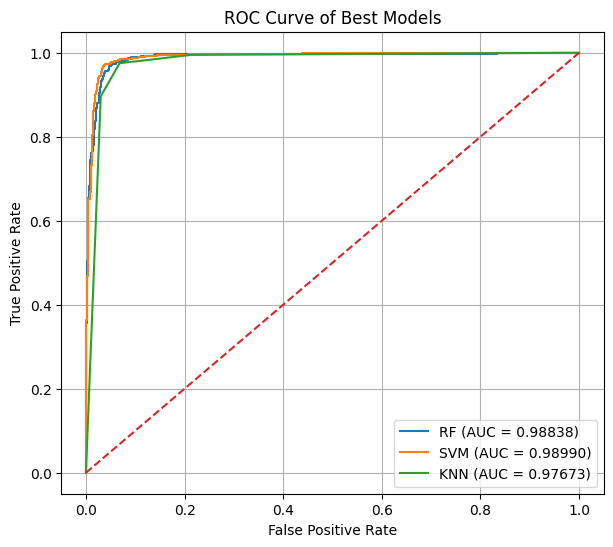

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = ["RF", "SVM", "KNN"]

plt.figure(figsize=(7,6))

for name in models:
    model = joblib.load(f"BEST_{name}_MODEL.pkl")
    X_test = np.load(f"BEST_{name}_X_test_comb.npy")
    y_test = np.load(f"BEST_{name}_y_test.npy")

   
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.5f})")


plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Best Models")
plt.legend()
plt.grid(True)
plt.show()